# Exercise: Building RNNs for Sequence Prediction
## AIAT 122 - Deep Learning

## Learning Objectives

- Implement RNN from scratch
- Apply RNN to time series prediction
- Compare vanilla RNN vs LSTM
- Understand vanishing gradient problem

## Real-World Context

You're building a stock price prediction system for a fintech company.

**Theory → Practice:** This exercise applies the theory and code patterns from `02_rnn_basics.ipynb` and `03_lstm_advanced.ipynb`. Complete those examples first if you haven't.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

**Expected:** When complete, you should see sequence data (shapes), training progress, and prediction metrics (e.g. loss or accuracy). Compare with the instructor solution after the deadline.

---


In [1]:
%pip install torch numpy pandas matplotlib -q

import torch
import torch.nn as nn
import numpy as np
import pandas as pd


import matplotlib.pyplot as plt

print('✅ Setup complete!')

Note: you may need to restart the kernel to use updated packages.


✅ Setup complete!


## Task 1: Generate Synthetic Time Series (15 points)

Create a synthetic stock price dataset with trend and seasonality.

In [2]:
# TODO: Generate synthetic time series data
# Hint: Use sine wave + trend + noise
def generate_stock_data(n=100):
    t = np.linspace(0, 4 * np.pi, n)
    x = np.sin(t) + 0.1 * t + 0.1 * np.random.randn(n)
    return torch.FloatTensor(x).reshape(-1, 1)


## Task 2: Implement Simple RNN (25 points)

Build a simple RNN model using PyTorch.

In [3]:
# TODO: Implement SimpleRNN class
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=8, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        h, _ = self.rnn(x)
        return self.fc(h)



## Task 3: Train RNN (30 points)

Train the RNN on stock data and evaluate performance.

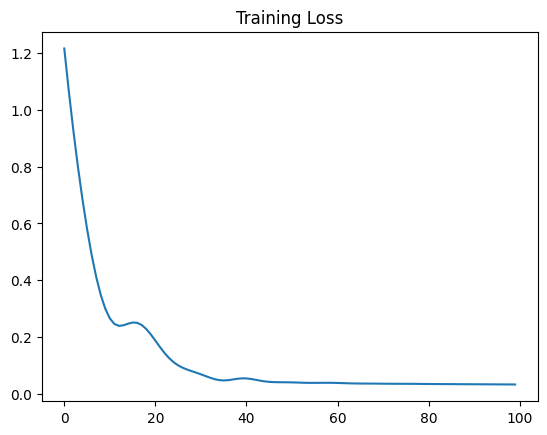

In [4]:
# TODO: Implement training loop
def train_rnn(model, data, epochs=100):
    losses = []
    opt = torch.optim.Adam(model.parameters(), lr=1e-2)
    X = data[:-1]
    y = data[1:]
    for _ in range(epochs):
        opt.zero_grad()
        out = model(X.unsqueeze(0))
        loss = nn.functional.mse_loss(out.squeeze(0), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

# Train
data = generate_stock_data()
model = SimpleRNN()
losses = train_rnn(model, data)
plt.plot(losses)
plt.title('Training Loss')
plt.show()

## Task 4: Compare with LSTM (30 points)

Implement LSTM and compare with vanilla RNN.

In [5]:
# TODO: Implement LSTM model
class LSTMModel(nn.Module):
    pass
 


## Submission

**Total: 100 points**

Submit completed notebook with:
1. All implementations
2. Training plots
3. Comparison analysis (2-3 sentences)

**Real-World Application**: Stock prediction, weather forecasting, sales forecasting

## 🌍 Real-World Worked Example — Stock Price Trend Prediction

**Industry context:** Hedge funds and trading platforms use LSTM models to predict price trends.  
Bloomberg Terminal, QuantConnect, and many hedge funds use sequence models for finance.

We use an LSTM to predict whether a **synthetic stock price** will go up or down next day.

In [ ]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

# ── Generate realistic stock-like price series ─────────────────────────────
np.random.seed(42)
n = 1000
price = np.cumsum(np.random.randn(n) * 0.5 + 0.05).astype(np.float32)  # random walk

# Create sequences: use 20 days to predict direction on day 21
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(price) - SEQ_LEN - 1):
    X_list.append(price[i:i+SEQ_LEN])
    y_list.append(1 if price[i+SEQ_LEN] > price[i+SEQ_LEN-1] else 0)

X_arr = np.array(X_list); y_arr = np.array(y_list)
# Normalise each sequence
X_arr = (X_arr - X_arr.mean(1,keepdims=True)) / (X_arr.std(1,keepdims=True)+1e-8)

split = int(0.8*len(X_arr))
Xtr = torch.tensor(X_arr[:split]).unsqueeze(-1)  # (N, 20, 1)
Ytr = torch.tensor(y_arr[:split], dtype=torch.long)
Xte = torch.tensor(X_arr[split:]).unsqueeze(-1)
Yte = torch.tensor(y_arr[split:], dtype=torch.long)

# ── LSTM Model ────────────────────────────────────────────────────────────
class TrendLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True, num_layers=2, dropout=0.2)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # last time step

model   = TrendLSTM()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(60):
    model.train()
    loss = loss_fn(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

model.eval()
with torch.no_grad():
    acc = (model(Xte).argmax(1)==Yte).float().mean().item()
print(f"Direction prediction accuracy: {acc*100:.1f}%")
print("(Random chance = 50%. Production models target 55-60% for profitable trading.)")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(price[:200]); plt.title("Synthetic Stock Price (200 days)"); plt.xlabel("Day"); plt.ylabel("Price")
plt.subplot(1,2,2)
plt.plot(losses); plt.title("LSTM Training Loss"); plt.xlabel("Epoch")
plt.tight_layout(); plt.show()

## 📚 References & Further Reading

**Papers:**
- Hochreiter & Schmidhuber (1997) — [Long Short-Term Memory](https://www.bioinf.jku.at/publications/older/2604.pdf)
- Cho et al. (2014) — [GRU: Learning Phrase Representations](https://arxiv.org/abs/1406.1078)

**PyTorch Docs:** [torch.nn.LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)

**State-of-the-Art:** LSTMs are still widely used in production for:
- Time series forecasting (Bloomberg, Reuters)
- Speech recognition in embedded systems (no internet)